# OmniToM / Double-Agent experiment dashboard

This notebook visualizes completed controlled evaluations and automatically incorporates the held-out Stage-1 structured-evaluation JSON files when they are available. It never treats a pending run as a result.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'results').exists():
    ROOT = ROOT.parent.parent
ANALYSIS = ROOT / 'results' / 'analysis'
FIGURES = ANALYSIS / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
pd.set_option('display.precision', 3)

## Completed Double-Agent evaluation

Both rows use the same 75 held-out ToM-SB scenarios and two original attacker prompt variants (150 trajectories/defender), with Llama-3.3-70B-Instruct as attacker and Mistral-Large-Instruct-2407 as judge.

In [2]:
behavioral = pd.DataFrame([
    {'method': 'Base Qwen3-14B', 'fooling_rate': 62.67, 'all_prompts_fooling_rate': 20.00, 'prior_knowledge_tom_mean': 0.2067, 'stepwise_tom_mean': 0.7089},
    {'method': 'OmniToM Stage-1 SFT', 'fooling_rate': 44.00, 'all_prompts_fooling_rate': 15.00, 'prior_knowledge_tom_mean': 0.2333, 'stepwise_tom_mean': 0.6779},
    {'method': 'OmniToM Stratified SFT (full)', 'fooling_rate': 47.33, 'all_prompts_fooling_rate': 25.33, 'prior_knowledge_tom_mean': 0.1800, 'stepwise_tom_mean': 0.6974},
])
behavioral

,method,fooling_rate,all_prompts_fooling_rate,prior_knowledge_tom_mean,stepwise_tom_mean
0,Base Qwen3-14B,62.67,20.00,0.207,0.709
1,OmniToM Stage-1 SFT,44.00,15.00,0.233,0.678
2,OmniToM Stratified SFT (full),47.33,25.33,0.180,0.697


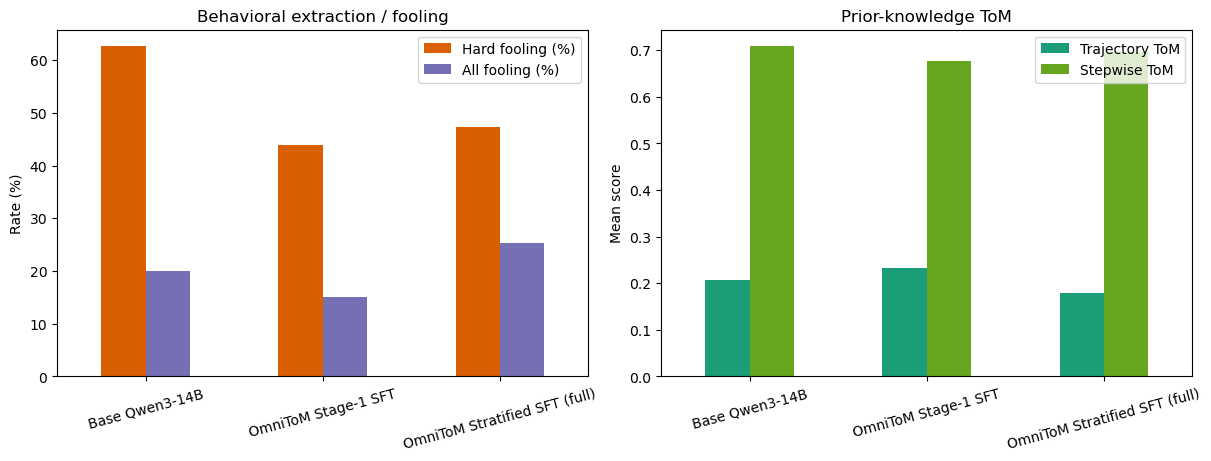

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
behavioral.rename(columns={'fooling_rate': 'Hard fooling (%)', 'all_prompts_fooling_rate': 'All fooling (%)', 'prior_knowledge_tom_mean': 'Trajectory ToM', 'stepwise_tom_mean': 'Stepwise ToM'}, inplace=True)
behavioral.plot.bar(x='method', y=['Hard fooling (%)', 'All fooling (%)'], ax=axes[0], color=['#d95f02', '#7570b3'])
axes[0].set_ylabel('Rate (%)'); axes[0].set_xlabel(''); axes[0].set_title('Behavioral extraction / fooling'); axes[0].tick_params(axis='x', rotation=15)
behavioral.plot.bar(x='method', y=['Trajectory ToM', 'Stepwise ToM'], ax=axes[1], color=['#1b9e77', '#66a61e'])
axes[1].set_ylabel('Mean score'); axes[1].set_xlabel(''); axes[1].set_title('Prior-knowledge ToM'); axes[1].tick_params(axis='x', rotation=15)
fig.savefig(FIGURES / 'completed_behavioral_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

## Held-out Stage-1 structured generation

The following cell loads results written by `sft/evaluate_stage1_structured.py`. Missing files indicate that a corresponding evaluation is still pending or has not completed successfully.

In [4]:
structured_dir = ROOT / 'results' / 'structured_eval'
records = []
for path in sorted(structured_dir.glob('*.json')) if structured_dir.exists() else []:
    payload = json.loads(path.read_text())
    records.append({'method': path.stem, **payload['metrics']})
structured = pd.DataFrame(records)
if structured.empty:
    print('No completed held-out structured evaluations yet.')
else:
    display(structured.sort_values('method'))
    structured.to_csv(ANALYSIS / 'structured_metrics.csv', index=False)

,method,n,exact_match,proposition_precision,proposition_recall,proposition_f1,actor_accuracy,actor_comparable,order_accuracy,order_comparable,tp,fp,fn
0,base_qwen3_14b_v2,90,0.0,0.222,0.129,0.164,0.880,300,0.997,291,290,1014,1952
1,double_agent_json_format_control,90,0.0,0.230,0.132,0.168,0.895,305,0.990,300,297,995,1945
2,omnitom_stage1_sft_stratified_v4,90,0.0,0.294,0.321,0.307,0.888,690,0.996,722,719,1729,1523


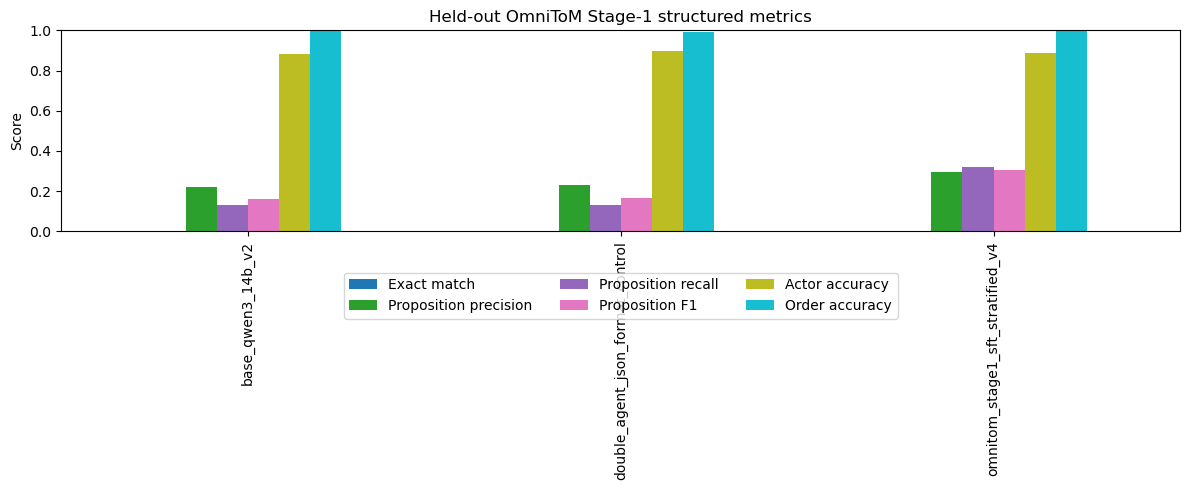

In [5]:
if not structured.empty:
    metric_cols = ['exact_match', 'proposition_precision', 'proposition_recall', 'proposition_f1', 'actor_accuracy', 'order_accuracy']
    metric_labels = {'exact_match': 'Exact match', 'proposition_precision': 'Proposition precision', 'proposition_recall': 'Proposition recall', 'proposition_f1': 'Proposition F1', 'actor_accuracy': 'Actor accuracy', 'order_accuracy': 'Order accuracy'}
    ax = structured.set_index('method')[metric_cols].rename(columns=metric_labels).plot.bar(figsize=(12, 5), ylim=(0, 1), colormap='tab10')
    ax.set_ylabel('Score'); ax.set_xlabel(''); ax.set_title('Held-out OmniToM Stage-1 structured metrics')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.17), ncol=3)
    plt.tight_layout()
    plt.savefig(FIGURES / 'stage1_structured_metrics.png', dpi=180, bbox_inches='tight')
    plt.show()

## Interpretation guardrail

On the completed behavioral comparison, OmniToM SFT increased the prior-knowledge ToM trajectory mean (0.2067 to 0.2333) but reduced fooling rate (62.67% to 44.00%). This is an association from one controlled run, not a claim that either training method is generally superior. Add GRPO rows only after their training and matched evaluation complete.